In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/Users/tharmmm/Documents/store_sale_project/store-sales-time-series-forecasting/train.csv")
df.head(20)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [4]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [5]:
df.shape

(3000888, 6)

### Check null value

In [6]:
df.isnull().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

### Number of unique store

In [7]:
print(np.sort(df["store_nbr"].unique()))
print(f"number of stores : {len(df['store_nbr'].unique())}")

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54]
number of stores : 54


### The number of stuff in store

In [8]:
print(df[df["store_nbr"] == 1]["family"].unique())
print(f"The number of unique family in one store : {len(df[df['store_nbr'] == 1]['family'].unique())}")

['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']
The number of unique family in one store : 33


In [9]:
for store, count in df.groupby("store_nbr")["family"].nunique().items():
    print(f"The number of unique family in store {store} : {count}")


The number of unique family in store 1 : 33
The number of unique family in store 2 : 33
The number of unique family in store 3 : 33
The number of unique family in store 4 : 33
The number of unique family in store 5 : 33
The number of unique family in store 6 : 33
The number of unique family in store 7 : 33
The number of unique family in store 8 : 33
The number of unique family in store 9 : 33
The number of unique family in store 10 : 33
The number of unique family in store 11 : 33
The number of unique family in store 12 : 33
The number of unique family in store 13 : 33
The number of unique family in store 14 : 33
The number of unique family in store 15 : 33
The number of unique family in store 16 : 33
The number of unique family in store 17 : 33
The number of unique family in store 18 : 33
The number of unique family in store 19 : 33
The number of unique family in store 20 : 33
The number of unique family in store 21 : 33
The number of unique family in store 22 : 33
The number of uniqu

In [10]:
df.groupby(["store_nbr","family"])["sales"].sum()

store_nbr  family                    
1          AUTOMOTIVE                    5.475000e+03
           BABY CARE                     0.000000e+00
           BEAUTY                        4.056000e+03
           BEVERAGES                     2.673769e+06
           BOOKS                         2.110000e+02
                                             ...     
54         POULTRY                       8.888981e+04
           PREPARED FOODS                1.030900e+05
           PRODUCE                       5.961803e+05
           SCHOOL AND OFFICE SUPPLIES    1.023000e+03
           SEAFOOD                       2.938000e+03
Name: sales, Length: 1782, dtype: float64

### Range of Date

In [11]:
print(f"Number of days : {df['date'].nunique()}")
print(f"Date range : {df['date'].min()} to {df['date'].max()}")


Number of days : 1684
Date range : 2013-01-01 to 2017-08-15


In [12]:
df.groupby("store_nbr")["date"].agg(["min", "max", "nunique"])

,min,max,nunique
store_nbr,,,
1,2013-01-01,2017-08-15,1684
2,2013-01-01,2017-08-15,1684
3,2013-01-01,2017-08-15,1684
4,2013-01-01,2017-08-15,1684
5,2013-01-01,2017-08-15,1684
6,2013-01-01,2017-08-15,1684
7,2013-01-01,2017-08-15,1684
8,2013-01-01,2017-08-15,1684
9,2013-01-01,2017-08-15,1684


### Daily Aggregated Distribution

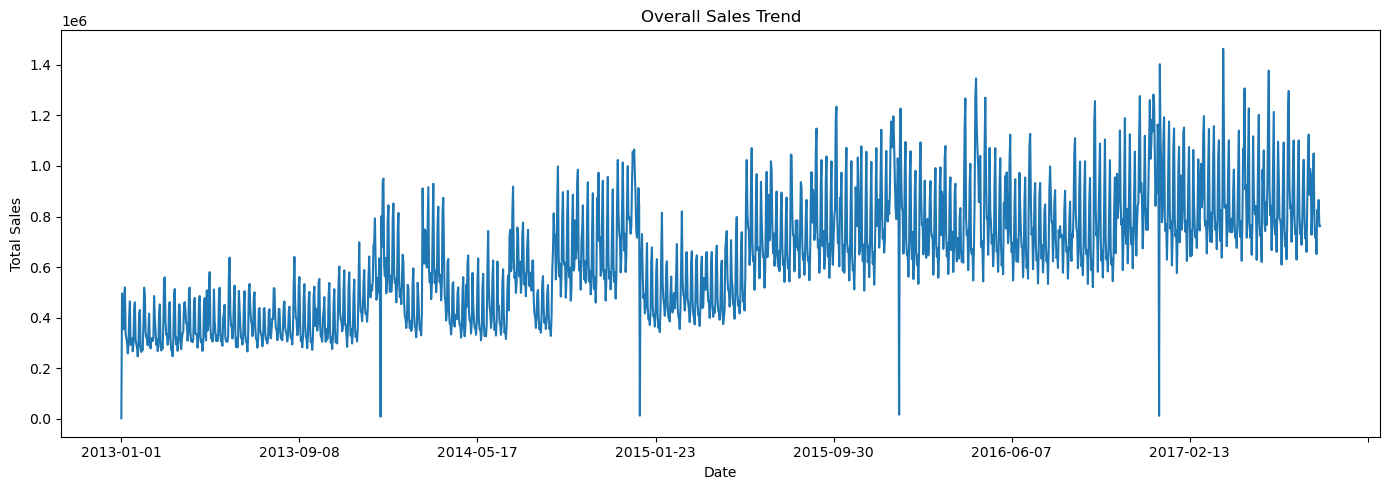

In [13]:
df.groupby("date")["sales"].sum().plot(figsize=(14, 5), title="Overall Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

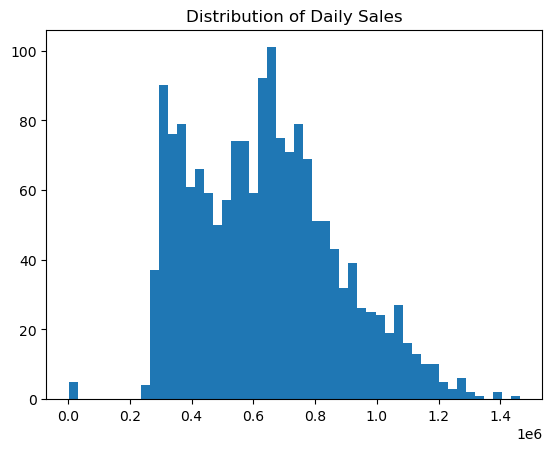

In [14]:
daily = df.groupby("date")["sales"].sum().reset_index()
plt.hist(daily["sales"], bins=50)
plt.title("Distribution of Daily Sales")
plt.show()

(array([2.885961e+06, 7.864300e+04, 2.147200e+04, 8.729000e+03,
        3.481000e+03, 1.696000e+03, 6.090000e+02, 1.850000e+02,
        6.700000e+01, 1.400000e+01, 6.000000e+00, 5.000000e+00,
        5.000000e+00, 2.000000e+00, 2.000000e+00, 2.000000e+00,
        1.000000e+00, 0.000000e+00, 2.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 1.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 2.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.000000e+00]),
 array([     0.  ,   2494.34,   4988.68,   7483.02,   9977.36,  12471.7 ,
         14966.04,  17460.38,  19954.72,  22449.06,  24943.4 ,  27437.74,
         29932.08,  32426.42,  34920.76,  3741

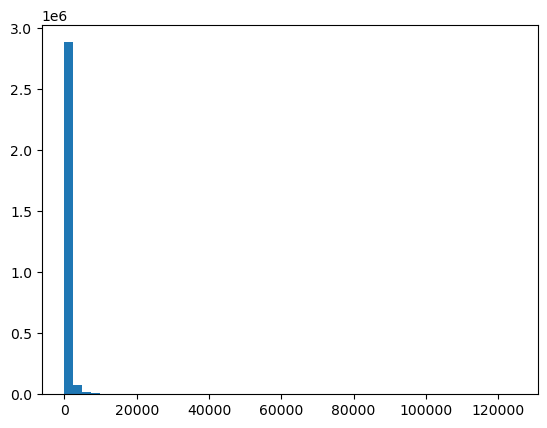

In [15]:
plt.hist(df['sales'], bins = 50)

The raw sales distribution is heavily right-skewed with extreme outliers and many near-zero values

In [16]:
print(f"Percentage of zero sales:: {((df['sales'] == 0).mean()*100):.2f} %")

Percentage of zero sales:: 31.30 %


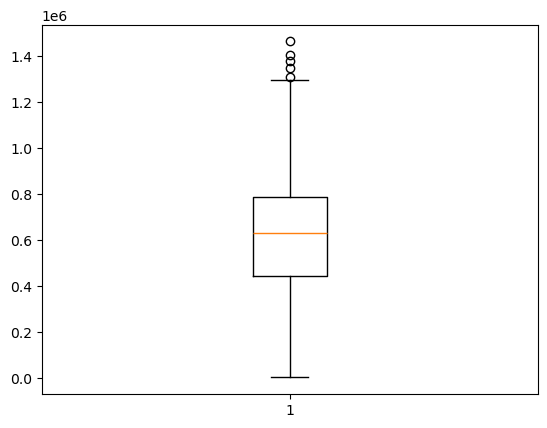

In [17]:
plt.boxplot(daily["sales"])
plt.show()

### Weekly Seasonality

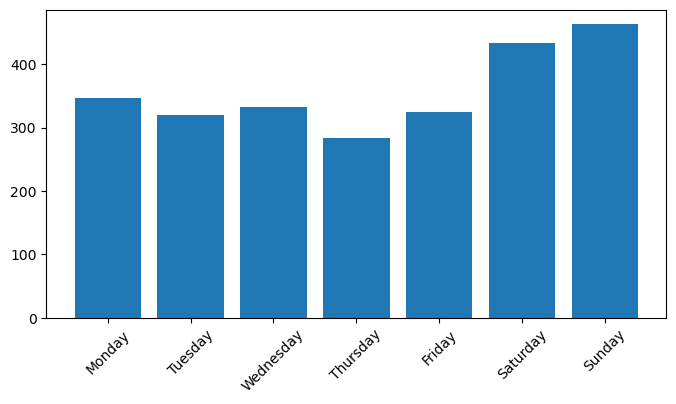

   day_of_week   day_name       sales
0            0     Monday  346.544732
1            1    Tuesday  319.823843
2            2  Wednesday  332.909401
3            3   Thursday  283.540517
4            4     Friday  325.238138
5            5   Saturday  433.336472
6            6     Sunday  463.085366


In [18]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.dayofweek
df['day_name'] = df['date'].dt.day_name()

day_sales = df.groupby(['day_of_week', 'day_name'])['sales'].mean().reset_index()

day_sales = day_sales.sort_values('day_of_week')
plt.figure(figsize=(8,4))
plt.bar(day_sales['day_name'], day_sales['sales'])
plt.xticks(rotation=45)
plt.show()

print(day_sales)


The bar chart shows that sales peak on Saturday and Sunday.

### Monthly Pattern

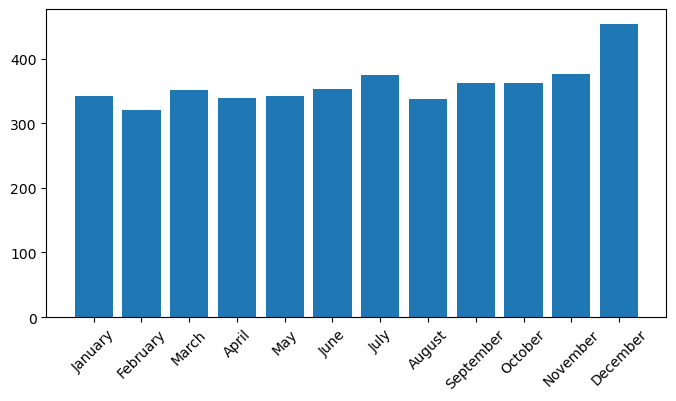

In [19]:
df["month"] = df["date"].dt.month
df['month_name'] = df['date'].dt.month_name()

month_sales = df.groupby(['month', 'month_name'])['sales'].mean().reset_index()
month_sales = month_sales.sort_values('month')

plt.figure(figsize=(8,4))
plt.bar(month_sales['month_name'], month_sales['sales'])
plt.xticks(rotation=45)
plt.show()

The bar chart shows that sales peak on December.

### Promotion Effect

onpromotion columnn is the number of product in that family are on promotion

In [20]:
df.groupby("onpromotion")["sales"].mean().head(20)

onpromotion
0      158.246681
1      467.556532
2      662.925632
3      871.408092
4      969.916135
5     1010.659835
6     1022.854287
7     1022.567058
8     1174.757003
9     1258.733993
10    1303.985479
11    1264.356349
12    1218.066159
13    1322.552007
14    1376.628033
15    1446.988239
16    1498.333841
17    1559.588638
18    1526.680412
19    1619.292366
Name: sales, dtype: float64

In [21]:
df.groupby(["family", "onpromotion"])["sales"].mean()

family      onpromotion
AUTOMOTIVE  0               5.853087
            1              12.271947
            2              13.480392
            3              15.923954
            4              18.936170
                             ...    
SEAFOOD     3              28.202830
            4              22.856937
            5              38.068377
            6              67.198554
            7              96.299518
Name: sales, Length: 1688, dtype: float64

In [22]:
df[["sales", "onpromotion"]].corr()

,sales,onpromotion
sales,1.000000,0.427923
onpromotion,0.427923,1.000000


<Axes: xlabel='onpromotion', ylabel='sales'>

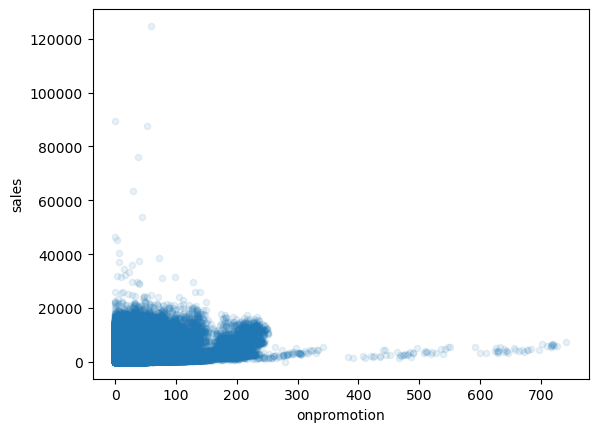

In [23]:
df.plot.scatter(x="onpromotion", y="sales", alpha=0.1)

choose top 5 family that have the highest sale

In [24]:
top_families = (
    df.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = df[df["family"].isin(top_families)]

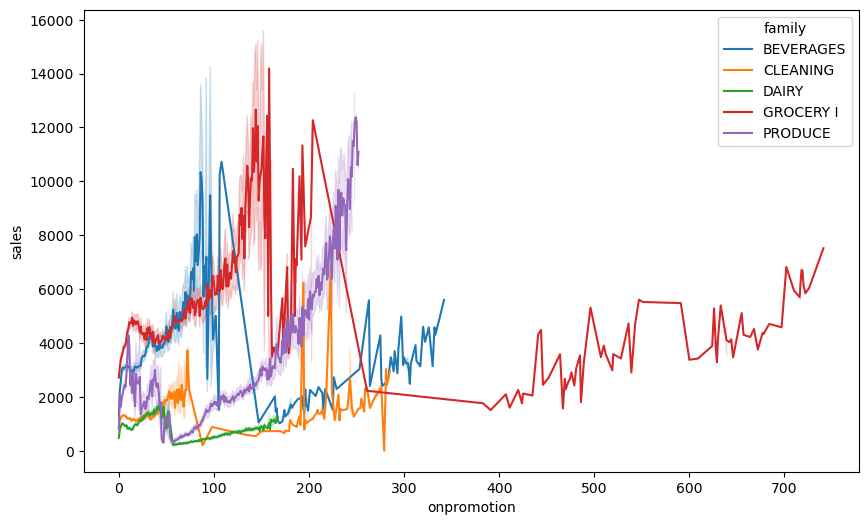

In [25]:
plt.figure(figsize=(10,6))
sns.lineplot(data=filtered,
             x="onpromotion",
             y="sales",
             hue="family",
             estimator="mean")
plt.show()

In [26]:
family_corr = (
    df.groupby("family")
      .apply(lambda x: x[["sales","onpromotion"]].corr().iloc[0,1])
)

/var/folders/6w/4xp185f12bs781fd1mwl2qvh0000gn/T/ipykernel_20143/1669827332.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[["sales","onpromotion"]].corr().iloc[0,1])


In [27]:
df.groupby("family")[["sales","onpromotion"]].corr()

sales  onpromotion
family                                                       
AUTOMOTIVE                 sales        1.000000     0.209826
                           onpromotion  0.209826     1.000000
BABY CARE                  sales        1.000000     0.054954
                           onpromotion  0.054954     1.000000
BEAUTY                     sales        1.000000     0.342411
...                                          ...          ...
PRODUCE                    onpromotion  0.356896     1.000000
SCHOOL AND OFFICE SUPPLIES sales        1.000000     0.669793
                           onpromotion  0.669793     1.000000
SEAFOOD                    sales        1.000000     0.289401
                           onpromotion  0.289401     1.000000

[66 rows x 2 columns]

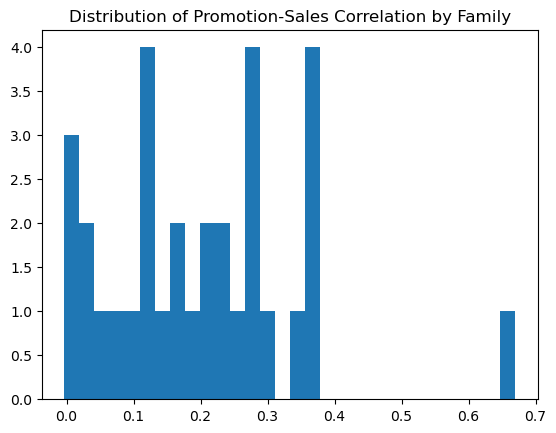

In [28]:
plt.hist(family_corr, bins=30)
plt.title("Distribution of Promotion-Sales Correlation by Family")
plt.show()

y-axis is number of family 

Promotion generally has a positive impact on sales across product families, although the strength of the relationship varies, with most families showing weak-to-moderate sensitivity.

In [29]:
print("top 5 family that got the most effect from promotion")
family_corr.sort_values(ascending=False).head()

top 5 family that got the most effect from promotion


family
SCHOOL AND OFFICE SUPPLIES    0.669793
BEVERAGES                     0.372682
HOME CARE                     0.369643
HOME AND KITCHEN II           0.362344
PRODUCE                       0.356896
dtype: float64

### Scope into store 

In [30]:
store_sale = df.groupby('store_nbr')['sales'].sum().sort_values()

In [31]:
print("Top 10 stores with the lowest total sales:")
print(store_sale.head(10))

print("\nTop 10 stores with the highest total sales:")
print(store_sale.sort_values(ascending=False).head(10))

Top 10 stores with the lowest total sales:
store_nbr
52    2.696170e+06
22    4.090202e+06
32    5.951796e+06
30    7.382074e+06
35    7.676679e+06
26    7.755122e+06
42    8.945768e+06
21    9.255506e+06
10    9.613906e+06
29    9.725158e+06
Name: sales, dtype: float64

Top 10 stores with the highest total sales:
store_nbr
44    6.208755e+07
45    5.449801e+07
47    5.094831e+07
3     5.048191e+07
49    4.342010e+07
46    4.189606e+07
48    3.593313e+07
51    3.291149e+07
8     3.049429e+07
50    2.865302e+07
Name: sales, dtype: float64


Store Sale distribution

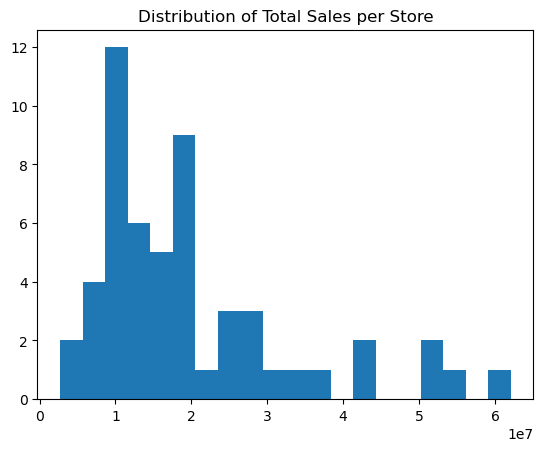

In [32]:
plt.hist(store_sale, bins=20)
plt.title("Distribution of Total Sales per Store")
plt.show()

In [33]:
store_sorted = store_sale.sort_values(ascending=False)

cumulative = store_sorted.cumsum() / store_sorted.sum()

cumulative.head(10)

store_nbr
44    0.057829
45    0.108589
47    0.156042
3     0.203061
49    0.243503
46    0.282525
48    0.315994
51    0.346648
8     0.375050
50    0.401738
Name: sales, dtype: float64

See weekly pattern store with highest sale vs lowest sale

In [34]:
top_store = store_sale.idxmax()
low_store = store_sale.idxmin()
df["date"] = pd.to_datetime(df["date"])
for s in [top_store, low_store]:
    temp = df[df["store_nbr"] == s].copy()
    temp["day_of_week"] = temp["date"].dt.dayofweek
    print(temp.groupby("day_of_week")["sales"].mean())

day_of_week
0    1002.204829
1     907.336428
2    1095.575595
3     819.458397
4    1026.714698
5    1446.719256
6    1523.563342
Name: sales, dtype: float64
day_of_week
0    45.194608
1    37.302187
2    48.650024
3    37.872254
4    51.006534
5    59.497875
6    60.154919
Name: sales, dtype: float64


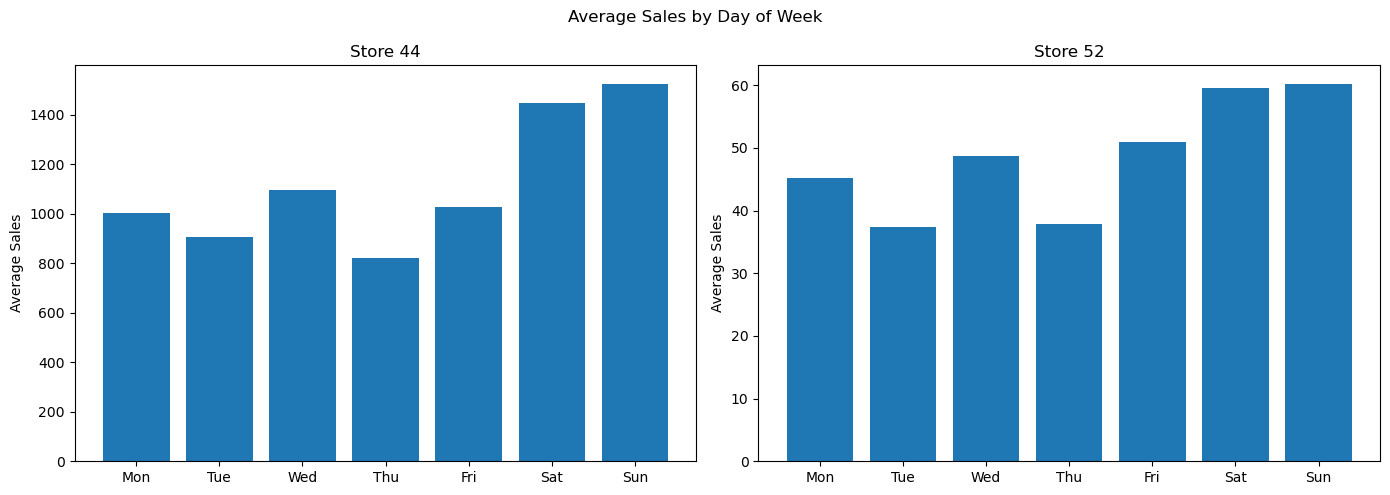

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

for ax, s in zip(axes, [top_store, low_store]):
    temp = df[df["store_nbr"] == s].copy()
    temp["day_of_week"] = temp["date"].dt.dayofweek
    daily = temp.groupby("day_of_week")["sales"].mean()
    ax.bar(day_names, daily)
    ax.set_title(f"Store {s}")
    ax.set_ylabel("Average Sales")

plt.suptitle("Average Sales by Day of Week")
plt.tight_layout()
plt.show()

### Product Category Analysis

In [36]:
family_std = df.groupby("family")["sales"].std().sort_values()
print (family_std.head())

family
BOOKS              0.547981
BABY CARE          0.681064
HOME APPLIANCES    0.969551
HARDWARE           1.638040
BEAUTY             4.794668
Name: sales, dtype: float64


In [37]:
family_std.tail()

family
DAIRY         671.949638
CLEANING      734.681493
PRODUCE      2186.481332
BEVERAGES    2307.882305
GROCERY I    2874.208845
Name: sales, dtype: float64

In [38]:
# Coefficient of Variation
family_stats = df.groupby("family")["sales"].agg(["mean","std"])
family_stats["cv"] = family_stats["std"] / family_stats["mean"]
family_stats.sort_values("cv")

,mean,std,cv
family,,,
CLEANING,1072.416744,734.681493,0.685071
GROCERY I,3776.972100,2874.208845,0.760982
DELI,265.135067,210.417073,0.793622
BREAD/BAKERY,463.336254,368.246367,0.794771
PERSONAL CARE,270.432513,226.512007,0.837592
EGGS,171.420516,161.826783,0.944034
DAIRY,709.154889,671.949638,0.947536
BEVERAGES,2385.793151,2307.882305,0.967344
AUTOMOTIVE,6.101236,6.191691,1.014826


### Zero Sales Analysis

In [39]:
(df["sales"] == 0).mean()

np.float64(0.3129506999261552)

In [40]:
# consider store level product level
zero_family = (
    df.assign(is_zero=(df["sales"]==0))
      .groupby("family")["is_zero"]
      .mean()
      .sort_values(ascending=False)
)

zero_family.head(10)

family
BOOKS                         0.969550
BABY CARE                     0.941310
SCHOOL AND OFFICE SUPPLIES    0.740829
HOME APPLIANCES               0.735176
LADIESWEAR                    0.598465
MAGAZINES                     0.565387
PET SUPPLIES                  0.546153
HARDWARE                      0.478622
LAWN AND GARDEN               0.467846
PLAYERS AND ELECTRONICS       0.448865
Name: is_zero, dtype: float64

In [41]:
# consider store level
zero_store = (
    df.assign(is_zero=(df["sales"]==0))
      .groupby("store_nbr")["is_zero"]
      .mean()
      .sort_values(ascending=False)
)

zero_store.head()

store_nbr
52    0.935399
22    0.685489
42    0.622166
21    0.613007
29    0.572177
Name: is_zero, dtype: float64

In [42]:
# consider day of week 
df["day_of_week"] = df["date"].dt.dayofweek

df.assign(is_zero=(df["sales"]==0)) \
  .groupby("day_of_week")["is_zero"] \
  .mean()

day_of_week
0    0.310172
1    0.314676
2    0.315025
3    0.317050
4    0.316353
5    0.297377
6    0.320064
Name: is_zero, dtype: float64

### Looking at holiday_event

In [43]:
df_holiday = pd.read_csv("/Users/tharmmm/Documents/store_sale_project/store-sales-time-series-forecasting/holidays_events.csv")
df_holiday['date'] = pd.to_datetime(df_holiday['date'])
df_holiday.head(10)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [44]:
print(df_holiday.shape)
print(df_holiday.describe())

(350, 6)
                                date
count                            350
mean   2015-04-24 00:45:15.428571392
min              2012-03-02 00:00:00
25%              2013-12-23 06:00:00
50%              2015-06-08 00:00:00
75%              2016-07-03 00:00:00
max              2017-12-26 00:00:00


In [45]:
df_holiday[df_holiday['transferred'] == True]


,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True
268,2016-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True
297,2017-01-01,Holiday,National,Ecuador,Primer dia del ano,True
303,2017-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,True
312,2017-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
324,2017-08-10,Holiday,National,Ecuador,Primer Grito de Independencia,True


In [46]:
df_holiday[df_holiday['transferred'] == True]['transferred'].count()

np.int64(12)

In [47]:
df_holiday[df_holiday['type'] == "Work Day"]

,date,type,locale,locale_name,description,transferred
42,2013-01-05,Work Day,National,Ecuador,Recupero puente Navidad,False
43,2013-01-12,Work Day,National,Ecuador,Recupero puente primer dia del ano,False
149,2014-12-20,Work Day,National,Ecuador,Recupero Puente Navidad,False
161,2015-01-10,Work Day,National,Ecuador,Recupero Puente Primer dia del ano,False
283,2016-11-12,Work Day,National,Ecuador,Recupero Puente Dia de Difuntos,False


In [48]:
df_holiday['type'].unique()

array(['Holiday', 'Transfer', 'Additional', 'Bridge', 'Work Day', 'Event'],
      dtype=object)

In [49]:
df_holiday[df_holiday['type'] == "Transfer"]

,date,type,locale,locale_name,description,transferred
20,2012-10-12,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
73,2013-10-11,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
136,2014-10-10,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False
256,2016-05-27,Transfer,National,Ecuador,Traslado Batalla de Pichincha,False
265,2016-07-24,Transfer,Local,Guayaquil,Traslado Fundacion de Guayaquil,False
269,2016-08-12,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False
298,2017-01-02,Transfer,National,Ecuador,Traslado Primer dia del ano,False
304,2017-04-13,Transfer,Local,Cuenca,Fundacion de Cuenca,False
313,2017-05-26,Transfer,National,Ecuador,Traslado Batalla de Pichincha,False
325,2017-08-11,Transfer,National,Ecuador,Traslado Primer Grito de Independencia,False


#### Clean df_holiday we get row that transferr == True and type != work day out

In [50]:
df_holidays_clean = df_holiday[
    (df_holiday["transferred"] == False) &
    (df_holiday["type"] != "Work Day")
]
print(f"before clean :{df_holiday.shape}")
print(f"after clean :{df_holidays_clean.shape}")

before clean :(350, 6)
after clean :(333, 6)


#### Merge holiday into train

In [51]:
df['date'] = pd.to_datetime(df['date'])
df = df.merge( df_holidays_clean[['date']], on= 'date', how = 'left')

df['is_holiday'] = df['date'].isin(df_holidays_clean['date']).astype(int)

df.head(10)

,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_name,month,month_name,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,Tuesday,1,January,1
1,1,2013-01-01,1,BABY CARE,0.0,0,1,Tuesday,1,January,1
2,2,2013-01-01,1,BEAUTY,0.0,0,1,Tuesday,1,January,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,Tuesday,1,January,1
4,4,2013-01-01,1,BOOKS,0.0,0,1,Tuesday,1,January,1
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0,1,Tuesday,1,January,1
6,6,2013-01-01,1,CELEBRATION,0.0,0,1,Tuesday,1,January,1
7,7,2013-01-01,1,CLEANING,0.0,0,1,Tuesday,1,January,1
8,8,2013-01-01,1,DAIRY,0.0,0,1,Tuesday,1,January,1
9,9,2013-01-01,1,DELI,0.0,0,1,Tuesday,1,January,1


#### Compare sale on holiday with non-holiday

In [52]:
df.groupby("is_holiday")['sales'].mean()

is_holiday
0    351.858132
1    397.033706
Name: sales, dtype: float64

In [53]:
daily = df.groupby(["date","is_holiday"])["sales"].sum().reset_index()
daily.groupby("is_holiday")["sales"].mean()

is_holiday
0    627011.192030
1    793363.050004
Name: sales, dtype: float64

In [54]:
print("holiday :",daily[daily['is_holiday'] == 1].shape)
print("non holiday :",daily[daily['is_holiday'] == 0].shape)

holiday : (239, 3)
non holiday : (1445, 3)


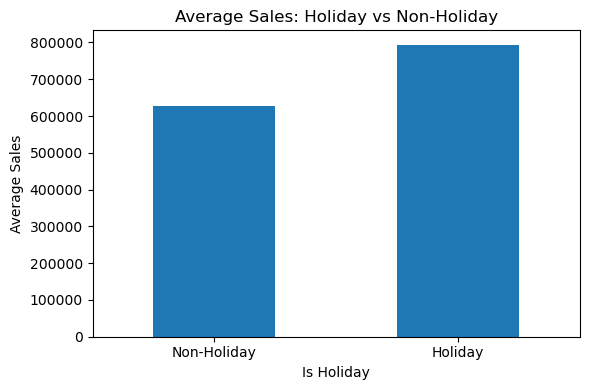

In [55]:
daily.groupby("is_holiday")["sales"].mean().plot(
    kind="bar",
    figsize=(6, 4),
    title="Average Sales: Holiday vs Non-Holiday",
    xlabel="Is Holiday",
    ylabel="Average Sales",
    xticks=[0, 1],
)
plt.xticks([0, 1], ["Non-Holiday", "Holiday"], rotation=0)
plt.tight_layout()
plt.show()

we can see that Average daily sales are significantly higher on holidays compared to non-holidays.

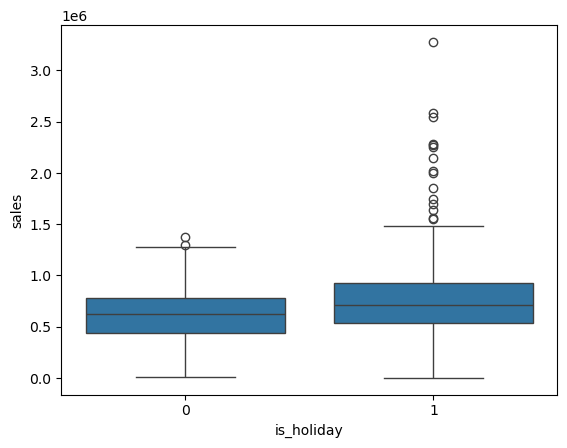

In [56]:
sns.boxplot(x="is_holiday", y="sales", data=daily)
plt.show()

In [57]:
df.groupby(["day_of_week","is_holiday"])["sales"].mean()

day_of_week  is_holiday
0            0             334.779955
             1             408.658331
1            0             313.875591
             1             353.904556
2            0             327.323284
             1             356.281241
3            0             277.039934
             1             346.024361
4            0             314.283771
             1             380.044810
5            0             429.468406
             1             463.092235
6            0             466.880407
             1             454.267427
Name: sales, dtype: float64

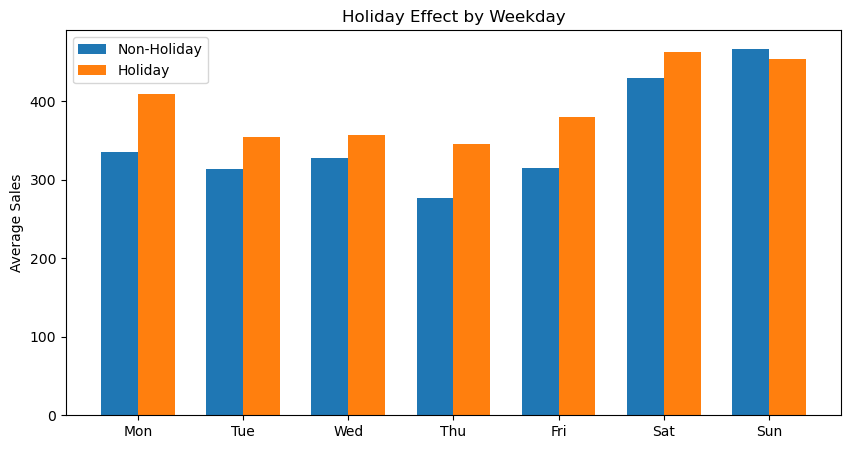

In [58]:
grouped = df.groupby(["day_of_week","is_holiday"])["sales"].mean()


non_holiday = []
holiday = []

for d in range(7):
    non_holiday.append(grouped[d][0])
    holiday.append(grouped[d][1])

x = np.arange(7)
width = 0.35

plt.figure(figsize=(10,5))
plt.bar(x - width/2, non_holiday, width, label="Non-Holiday")
plt.bar(x + width/2, holiday, width, label="Holiday")

plt.xticks(x, ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.ylabel("Average Sales")
plt.title("Holiday Effect by Weekday")
plt.legend()
plt.show()

We can see that if holiday is on relugular day , sale significantly increase. On the other hand, slightly incrasing on Saturaday and decrease on Sunday.

#### Consider day have earthquake

In [59]:
df_holidays_clean[df_holidays_clean['type'] == 'Event']

,date,type,locale,locale_name,description,transferred
55,2013-05-12,Event,National,Ecuador,Dia de la Madre,False
103,2014-05-11,Event,National,Ecuador,Dia de la Madre,False
106,2014-06-12,Event,National,Ecuador,Inauguracion Mundial de futbol Brasil,False
107,2014-06-15,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Suiza,False
108,2014-06-20,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Honduras,False
113,2014-06-25,Event,National,Ecuador,Mundial de futbol Brasil: Ecuador-Francia,False
114,2014-06-28,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
115,2014-06-29,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
116,2014-06-30,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False
117,2014-07-01,Event,National,Ecuador,Mundial de futbol Brasil: Octavos de Final,False


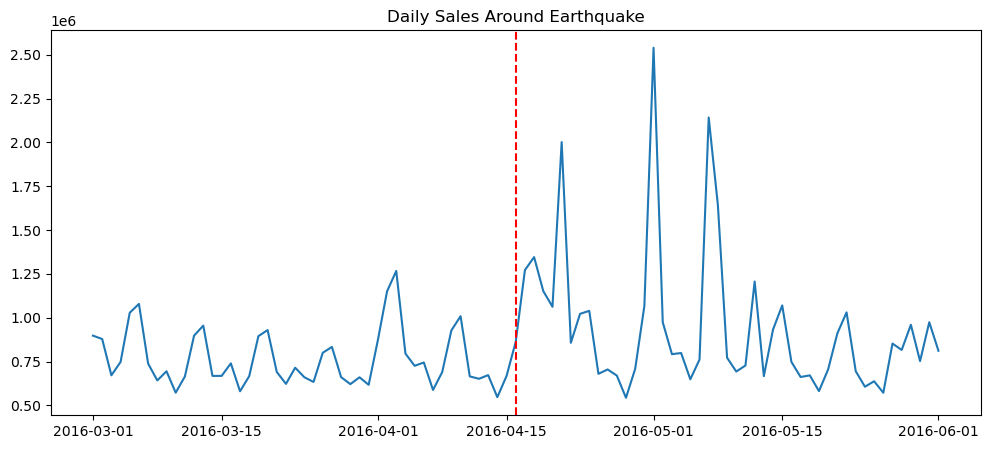

In [60]:
daily = df.groupby("date")["sales"].sum().reset_index()

mask = (daily["date"] >= "2016-03-01") & (daily["date"] <= "2016-06-01")
subset = daily[mask]

plt.figure(figsize=(12,5))
plt.plot(subset["date"], subset["sales"])
plt.axvline(pd.to_datetime("2016-04-16"), color="red", linestyle="--")
plt.title("Daily Sales Around Earthquake")
plt.show()

In [61]:
quake_date = pd.to_datetime("2016-04-16")

before = daily[
    (daily["date"] >= quake_date - pd.Timedelta(days=30)) &
    (daily["date"] < quake_date)
]["sales"].mean()

after = daily[
    (daily["date"] > quake_date) &
    (daily["date"] <= quake_date + pd.Timedelta(days=30))
]["sales"].mean()

print("Before:", before)
print("After:", after)

Before: 752054.2500009133
After: 1041466.0620713701


In [62]:
((after - before) / before) * 100

np.float64(38.482837118479864)

In [63]:
df_holidays_clean[
    (df_holidays_clean["date"] >= "2016-04-01") &
    (df_holidays_clean["date"] <= "2016-05-30")
]

,date,type,locale,locale_name,description,transferred
216,2016-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
217,2016-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
218,2016-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
219,2016-04-16,Event,National,Ecuador,Terremoto Manabi,False
220,2016-04-17,Event,National,Ecuador,Terremoto Manabi+1,False
221,2016-04-18,Event,National,Ecuador,Terremoto Manabi+2,False
222,2016-04-19,Event,National,Ecuador,Terremoto Manabi+3,False
223,2016-04-20,Event,National,Ecuador,Terremoto Manabi+4,False
224,2016-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
225,2016-04-21,Event,National,Ecuador,Terremoto Manabi+5,False


we can see Earth quake impact 30 day after it occur

Create feature for Earthquake

In [64]:
df["is_earthquake"] = df["date"].isin(
    df_holidays_clean[df_holidays_clean["description"].str.contains("Terremoto")]["date"]
).astype(int)

df[df['is_earthquake'] == 1]

,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_name,month,month_name,is_holiday,is_earthquake
2161566,2134836,2016-04-16,1,AUTOMOTIVE,6.000,0,5,Saturday,4,April,1,1
2161567,2134837,2016-04-16,1,BABY CARE,0.000,0,5,Saturday,4,April,1,1
2161568,2134838,2016-04-16,1,BEAUTY,4.000,0,5,Saturday,4,April,1,1
2161569,2134839,2016-04-16,1,BEVERAGES,2073.000,5,5,Saturday,4,April,1,1
2161570,2134840,2016-04-16,1,BOOKS,0.000,0,5,Saturday,4,April,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2225713,2190073,2016-05-16,9,POULTRY,426.926,1,0,Monday,5,May,1,1
2225714,2190074,2016-05-16,9,PREPARED FOODS,92.723,0,0,Monday,5,May,1,1
2225715,2190075,2016-05-16,9,PRODUCE,1431.665,1,0,Monday,5,May,1,1
2225716,2190076,2016-05-16,9,SCHOOL AND OFFICE SUPPLIES,9.000,0,0,Monday,5,May,1,1


Create feature for Event without earthquake

In [65]:
df_holidays_clean["is_other_event"] = (
    (df_holidays_clean["type"] == "Event") &
    (~df_holidays_clean["description"].str.contains("Terremoto"))
).astype(int)

df = df.merge(df_holidays_clean[["date", "is_other_event"]], on="date", how="left")
df["is_other_event"] = df["is_other_event"].fillna(0).astype(int)

df.head(5)

/var/folders/6w/4xp185f12bs781fd1mwl2qvh0000gn/T/ipykernel_20143/2520902401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_holidays_clean["is_other_event"] = (


,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_name,month,month_name,is_holiday,is_earthquake,is_other_event
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,Tuesday,1,January,1,0,0
1,1,2013-01-01,1,BABY CARE,0.0,0,1,Tuesday,1,January,1,0,0
2,2,2013-01-01,1,BEAUTY,0.0,0,1,Tuesday,1,January,1,0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,Tuesday,1,January,1,0,0
4,4,2013-01-01,1,BOOKS,0.0,0,1,Tuesday,1,January,1,0,0


we will push Holiday Transfer Bridge and Additional in is_holiday except event and earth quake

In [66]:
df.drop(columns=["is_holiday"], inplace=True) # drop old column first

In [67]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_name,month,month_name,is_earthquake,is_other_event
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,Tuesday,1,January,0,0
1,1,2013-01-01,1,BABY CARE,0.0,0,1,Tuesday,1,January,0,0
2,2,2013-01-01,1,BEAUTY,0.0,0,1,Tuesday,1,January,0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,Tuesday,1,January,0,0
4,4,2013-01-01,1,BOOKS,0.0,0,1,Tuesday,1,January,0,0


In [68]:
holiday_types = ["Holiday", "Transfer", "Bridge", "Additional"]

holiday_dates = df_holidays_clean.loc[
    (df_holidays_clean["transferred"] == False) &
    (df_holidays_clean["type"].isin(holiday_types)),
    "date"
]

df["is_holiday"] = df["date"].isin(holiday_dates).astype(int)

In [69]:
df.shape

(3180870, 13)

In [71]:
df.head()

,id,date,store_nbr,family,sales,onpromotion,day_of_week,day_name,month,month_name,is_earthquake,is_other_event,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,1,Tuesday,1,January,0,0,1
1,1,2013-01-01,1,BABY CARE,0.0,0,1,Tuesday,1,January,0,0,1
2,2,2013-01-01,1,BEAUTY,0.0,0,1,Tuesday,1,January,0,0,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,1,Tuesday,1,January,0,0,1
4,4,2013-01-01,1,BOOKS,0.0,0,1,Tuesday,1,January,0,0,1


In [70]:
df_holidays_clean.head()

,date,type,locale,locale_name,description,transferred,is_other_event
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False,0
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False,0
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False,0
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False,0
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False,0
